<a href="https://colab.research.google.com/github/princealexanderm/-ICT_AI_ML/blob/main/ICT_AI_ML__Intermediate_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.analyticsvidhya.com/datahack/contest/wns-analytics-hackathon-2018-1/

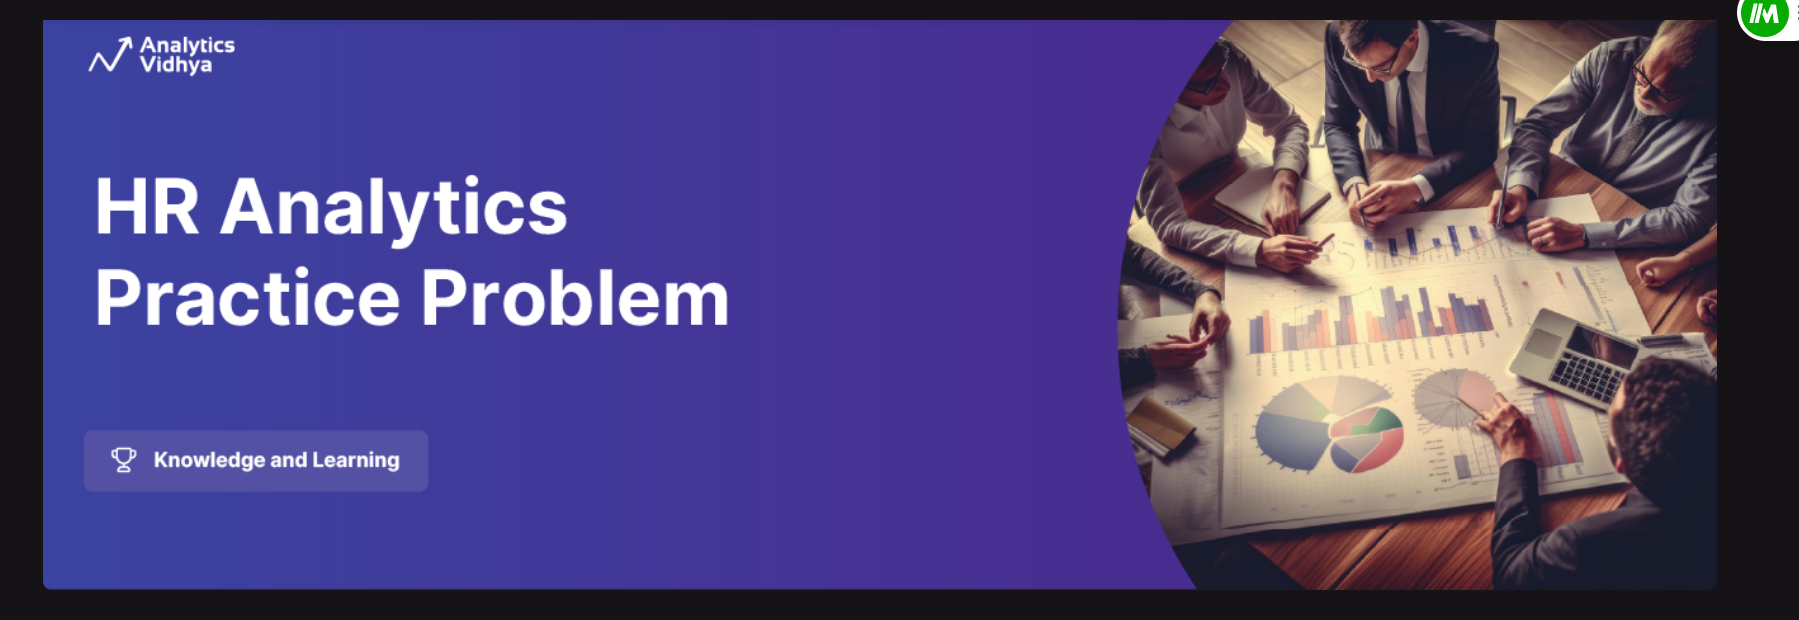

**WNS Analytics Wizard 2018**

Your client is a large MNC and they have 9 broad verticals across the organisation. One of the problem your client is facing is around identifying the right people for promotion (only for manager position and below) and prepare them in time. Currently the process, they are following is:

- They first identify a set of employees based on recommendations/ past performance
- Selected employees go through the separate training and evaluation program for each vertical. These programs are based on the required skill of each vertical
- At the end of the program, based on various factors such as training performance, KPI completion (only employees with KPIs completed greater than 60% are considered) etc., employee gets promotion

For above mentioned process, the final promotions are only announced after the evaluation and this leads to delay in transition to their new roles. Hence, company needs your help in identifying the eligible candidates at a particular checkpoint so that they can expedite the entire promotion cycle.

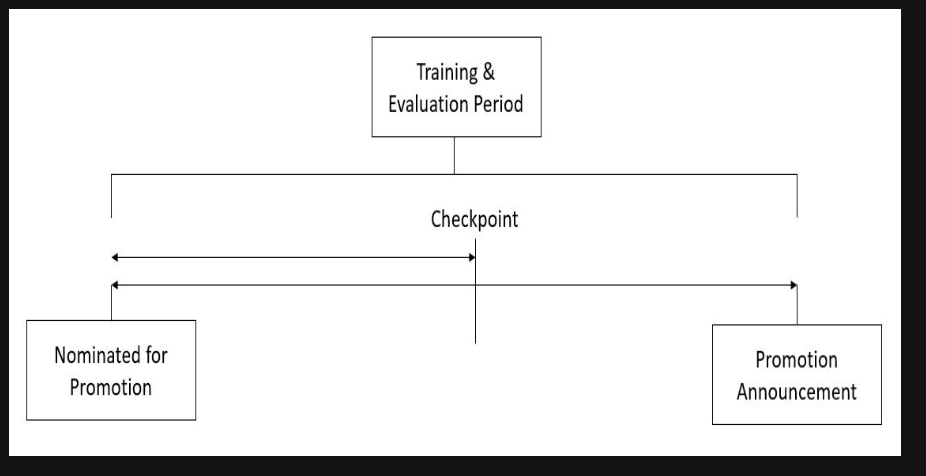

They have provided multiple attributes around Employee's past and current performance along with demographics. Now, The task is to predict whether a potential promotee at checkpoint in the test set will be promoted or not after the evaluation process.

# 1. importing necessary modules

In [371]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Loading the data

In [372]:
df=pd.read_csv('/content/train_LZdllcl.csv')
df.sample(10)

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
15736,59720,Technology,region_10,Master's & above,f,sourcing,1,33,4.0,7,0,0,82,0
21426,45124,Procurement,region_8,Master's & above,f,sourcing,1,34,3.0,3,0,0,73,0
45587,48665,Technology,region_5,Bachelor's,m,other,1,33,3.0,4,0,0,82,0
2513,77874,Technology,region_27,Bachelor's,m,sourcing,1,32,3.0,9,0,0,76,0
4826,689,Procurement,region_2,Master's & above,m,other,1,42,3.0,2,0,0,69,0
46444,46387,Operations,region_2,Bachelor's,f,other,1,29,3.0,2,1,0,55,0
26567,32160,Finance,region_11,Bachelor's,m,other,1,28,5.0,4,1,0,58,0
46930,49215,Analytics,region_32,Bachelor's,m,other,1,28,4.0,6,1,0,82,0
34316,13571,Analytics,region_19,Bachelor's,m,other,1,30,3.0,4,0,0,87,0
37250,42806,Procurement,region_7,Master's & above,m,other,1,40,1.0,3,0,0,71,0


# 3. Shpae of the data

In [373]:
df.shape

(54808, 14)

# 4. Basic info of the data

In [374]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


# 5. Summary statistics of the data

In [375]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


# 6. Number of classes in target column

In [376]:
df['is_promoted'].value_counts()

,count
is_promoted,
0,50140
1,4668


Two:0 and 1

Its a binary problem

# 7. Identifying missing value

In [377]:
df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


- Education is an object type data type
- previous year rating is a numerical data type

#8. Numerical columns

In [378]:
df_numerical_columns = df.select_dtypes(include=np.number)
df_numerical_columns

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,1,35,5.0,8,1,0,49,0
1,65141,1,30,5.0,4,0,0,60,0
2,7513,1,34,3.0,7,0,0,50,0
3,2542,2,39,1.0,10,0,0,50,0
4,48945,1,45,3.0,2,0,0,73,0
...,...,...,...,...,...,...,...,...,...
54803,3030,1,48,3.0,17,0,0,78,0
54804,74592,1,37,2.0,6,0,0,56,0
54805,13918,1,27,5.0,3,1,0,79,0
54806,13614,1,29,1.0,2,0,0,45,0


# 9. Categorical columns

In [379]:
df_categorical_columns = df.select_dtypes(include='object')
df_categorical_columns

,department,region,education,gender,recruitment_channel
0,Sales & Marketing,region_7,Master's & above,f,sourcing
1,Operations,region_22,Bachelor's,m,other
2,Sales & Marketing,region_19,Bachelor's,m,sourcing
3,Sales & Marketing,region_23,Bachelor's,m,other
4,Technology,region_26,Bachelor's,m,other
...,...,...,...,...,...
54803,Technology,region_14,Bachelor's,m,sourcing
54804,Operations,region_27,Master's & above,f,other
54805,Analytics,region_1,Bachelor's,m,other
54806,Sales & Marketing,region_9,NaN,m,sourcing


# 10.Box plot of numerical columns

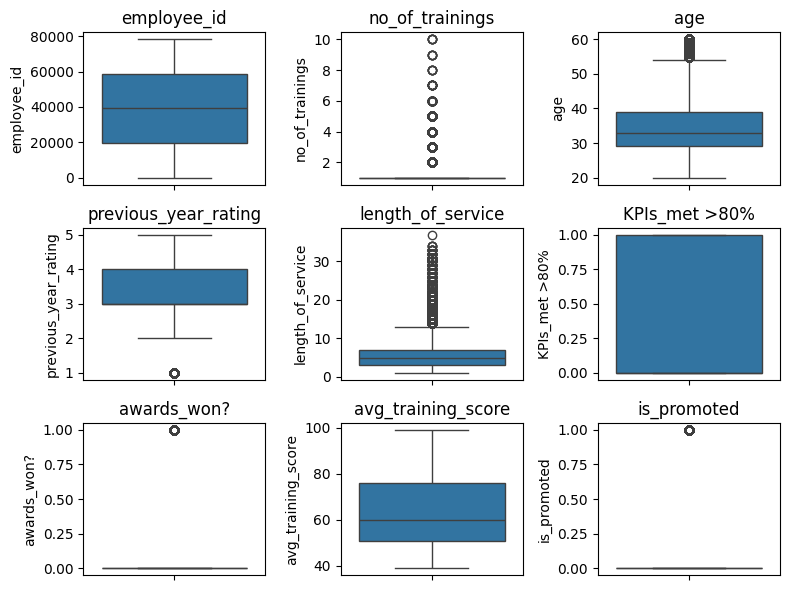

In [380]:
fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.ravel()

for i, col in enumerate(df_numerical_columns.columns):
    sns.boxplot(y=df_numerical_columns[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# 11. Histogram of numerical columsn

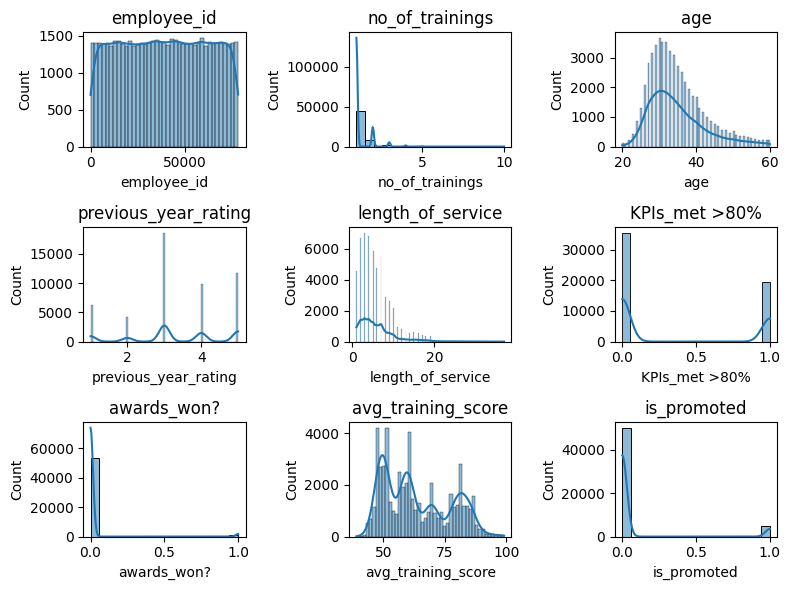

In [381]:
fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.ravel()

for i, col in enumerate(df_numerical_columns.columns):
    sns.histplot(data=df_numerical_columns, x=col, ax=axes[i], kde=True)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

<Axes: >

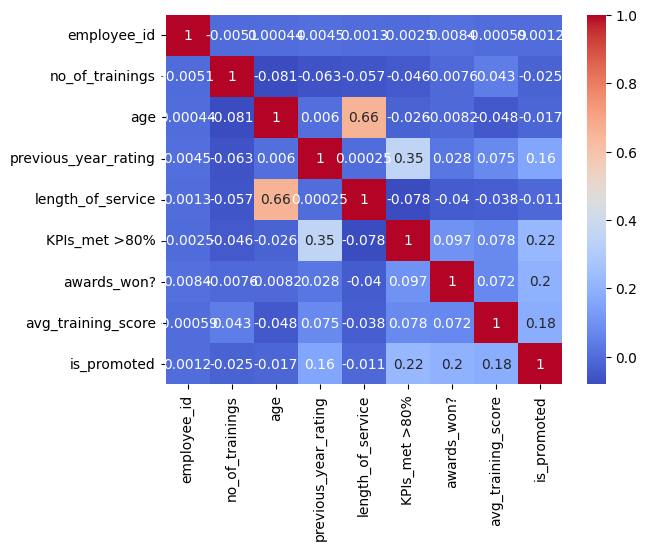

In [382]:
corr_matrix=df_numerical_columns.corr()
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')

# 12. Box plot of categorical columns

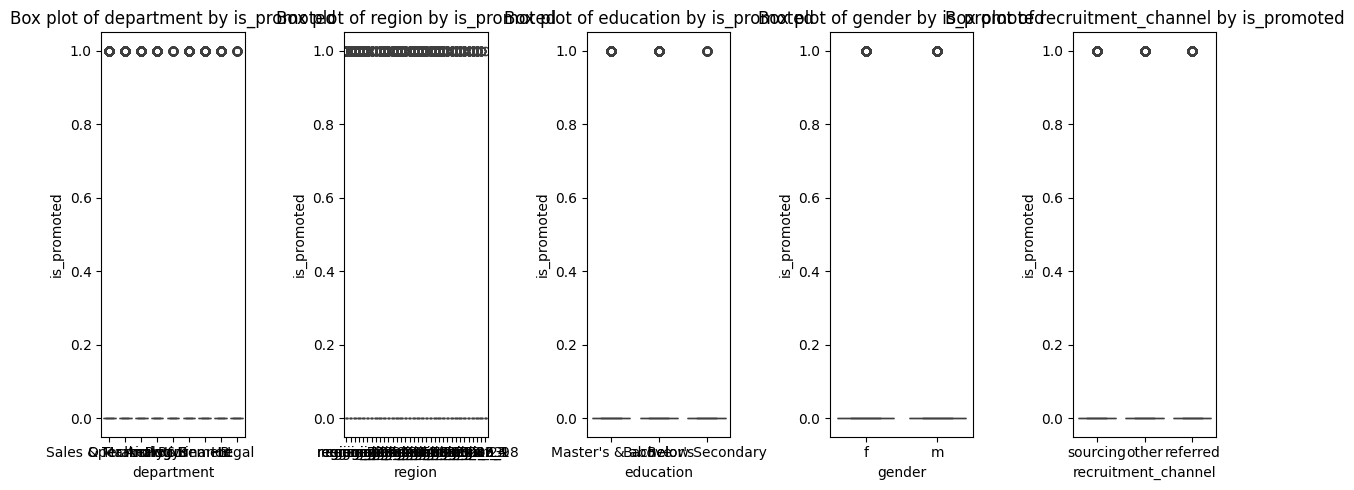

In [383]:
fig, axes = plt.subplots(1, 5, figsize=(12, 5))
axes = axes.ravel()

for i, col in enumerate(df_categorical_columns.columns):
    sns.boxplot(data=df, x=col, y='is_promoted', ax=axes[i])
    axes[i].set_title(f'Box plot of {col} by is_promoted')

plt.tight_layout()
plt.show()

# 13. Missing value handling

In [384]:
df['education'].value_counts()

,count
education,
Bachelor's,36669
Master's & above,14925
Below Secondary,805


In [385]:
df['previous_year_rating'].value_counts()

,count
previous_year_rating,
3.0,18618
5.0,11741
4.0,9877
1.0,6223
2.0,4225


Fill numerical missing value with mode and categorical missing value with

In [386]:
df['education'].fillna(df['education'].mode()[0], inplace=True)
df['previous_year_rating'].fillna(df['previous_year_rating'].mean(), inplace=True)

<ipython-input-386-96ec864787fe>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['education'].fillna(df['education'].mode()[0], inplace=True)
<ipython-input-386-96ec864787fe>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

# 14. Label encoding categorical columns

In [387]:
from sklearn.preprocessing import LabelEncoder
categorical_cols = ['department', 'region', 'education', 'gender', 'recruitment_channel']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [388]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,7,31,2,0,2,1,35,5.0,8,1,0,49,0
1,65141,4,14,0,1,0,1,30,5.0,4,0,0,60,0
2,7513,7,10,0,1,2,1,34,3.0,7,0,0,50,0
3,2542,7,15,0,1,0,2,39,1.0,10,0,0,50,0
4,48945,8,18,0,1,0,1,45,3.0,2,0,0,73,0


In [389]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  int64  
 2   region                54808 non-null  int64  
 3   education             54808 non-null  int64  
 4   gender                54808 non-null  int64  
 5   recruitment_channel   54808 non-null  int64  
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  54808 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(13)
memory usage: 5.9 MB


# 15. Splitting features and target

In [390]:
X = df.drop(['employee_id', 'is_promoted'], axis=1)
y = df['is_promoted']

In [391]:
X.shape

(54808, 12)

# 16. Splitting in to traiing and testing

In [392]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 17. Scaling the data

In [393]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 18. Logistic Regression

In [394]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

## Evaluation

In [395]:
y_pred_lr=lr.predict(X_test)

In [396]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score,f1_score
print('Accuracy is', accuracy_score(y_test, y_pred_lr))
print('Precision is', precision_score(y_test, y_pred_lr))
print('Recall is', recall_score(y_test, y_pred_lr))
print('f1 score is', f1_score(y_test,y_pred_lr))

Accuracy is 0.9178069695311074
Precision is 0.6434782608695652
Recall is 0.07922912205567452
f1 score is 0.14108674928503337


#19. SVM

In [397]:
from sklearn.svm import SVC
svm=SVC()
svm.fit(X_train,y_train)

SVC()

In [398]:
y_pred_svm=svm.predict(X_test)

In [399]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score,f1_score
print('Accuracy is', accuracy_score(y_test, y_pred_svm))
print('Precision is', precision_score(y_test, y_pred_svm))
print('Recall is', recall_score(y_test, y_pred_svm))
print('f1 score is', f1_score(y_test,y_pred_svm))

Accuracy is 0.922824302134647
Precision is 0.8859649122807017
Recall is 0.10813704496788008
f1 score is 0.19274809160305342


#20. DecisionTree

In [400]:
from sklearn.tree import DecisionTreeClassifier
DT=DecisionTreeClassifier()
DT.fit(X_train,y_train)

DecisionTreeClassifier()

In [401]:
y_pred_DT=DT.predict(X_test)

In [402]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score,f1_score
print('Accuracy is', accuracy_score(y_test, y_pred_DT))
print('Precision is', precision_score(y_test, y_pred_DT))
print('Recall is', recall_score(y_test, y_pred_DT))
print('f1 score is', f1_score(y_test,y_pred_DT))

Accuracy is 0.8881590950556468
Precision is 0.3684684684684685
Recall is 0.43790149892933616
f1 score is 0.40019569471624267


# 21. RandomForest

In [403]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

In [404]:
y_pred_rf=rf.predict(X_test)

In [405]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score,f1_score
print('Accuracy is', accuracy_score(y_test, y_pred_rf))
print('Precision is', precision_score(y_test, y_pred_rf))
print('Recall is', recall_score(y_test, y_pred_rf))
print('f1 score is', f1_score(y_test,y_pred_rf))

Accuracy is 0.934227330779055
Precision is 0.8380952380952381
Recall is 0.2826552462526767
f1 score is 0.42273819055244194


#22. KNN

In [406]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [407]:
y_pred_knn=knn.predict(X_test)

In [408]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score,f1_score
print('Accuracy is', accuracy_score(y_test, y_pred_knn))
print('Precision is', precision_score(y_test, y_pred_knn))
print('Recall is', recall_score(y_test, y_pred_knn))
print('f1 score is', f1_score(y_test,y_pred_knn))

Accuracy is 0.8825944170771757
Precision is 0.2901307966706302
Recall is 0.26124197002141325
f1 score is 0.27492957746478874


#23. xg boost

In [409]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [410]:
y_pred_xgb = xgb_model.predict(X_test)
print('Accuracy is', accuracy_score(y_test, y_pred_xgb))
print('Precision is', precision_score(y_test, y_pred_xgb))
print('Recall is', recall_score(y_test, y_pred_xgb))
print('f1 score is', f1_score(y_test, y_pred_xgb))

Accuracy is 0.9426199598613392
Precision is 0.9023746701846965
Recall is 0.36616702355460384
f1 score is 0.5209444021325209


#24. Gradient boost

In [411]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

GradientBoostingClassifier()

In [412]:
y_pred_gb = gb_model.predict(X_test)
print('Accuracy is', accuracy_score(y_test, y_pred_gb))
print('Precision is', precision_score(y_test, y_pred_gb))
print('Recall is', recall_score(y_test, y_pred_gb))
print('f1 score is', f1_score(y_test, y_pred_gb))

Accuracy is 0.9379675241744208
Precision is 0.9703703703703703
Recall is 0.28051391862955033
f1 score is 0.43521594684385384


# XG boost gave the best result

# 25. Loading the given test data

In [421]:
X_test_a=pd.read_csv('/content/test_2umaH9m.csv')
X_test_a.head(5)

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61


In [422]:
X_test_a.shape

(23490, 13)

In [423]:
X_test_a['education'].fillna(X_test_a['education'].mode()[0], inplace=True)
X_test_a['previous_year_rating'].fillna(X_test_a['previous_year_rating'].mean(), inplace=True)

<ipython-input-423-ed90ff409fdc>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test_a['education'].fillna(X_test_a['education'].mode()[0], inplace=True)
<ipython-input-423-ed90ff409fdc>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(va

In [424]:
X_test_a = X_test_a.drop(['employee_id'], axis=1)
X_test_a.head(5)
X_test_a.shape

(23490, 12)

In [425]:
X_train.shape

(43846, 12)

In [426]:
from sklearn.preprocessing import LabelEncoder
categorical_cols = ['department', 'region', 'education', 'gender', 'recruitment_channel']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_test_a[col] = le.fit_transform(X_test_a[col])
    label_encoders[col] = le

In [427]:
X_test_a.head(5)

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8,18,0,1,2,1,24,3.339146,1,1,0,77
1,2,28,0,0,0,1,31,3.000000,5,0,0,51
2,7,4,0,1,0,1,31,1.000000,4,0,0,47
3,5,11,0,0,0,3,31,2.000000,9,0,0,65
4,1,21,0,1,2,1,30,4.000000,7,0,0,61


In [428]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_test_a = scaler.fit_transform(X_test_a)
#X_test = scaler.transform(X_test)

# 26. Predicting y using testing data

In [430]:
y_pred_final = xgb_model.predict(X_test_a)
y_pred_final

array([1, 0, 0, ..., 0, 0, 1])

# 27. Loading sample submission file

In [433]:
df_sample=pd.read_csv('/content/sample_submission_M0L0uXE.csv')

In [434]:
df_sample.head(5)

,employee_id,is_promoted
0,8724,0
1,74430,0
2,72255,0
3,38562,0
4,64486,0


# 28. Replacing target column in sample submission file with y_pred_final

In [435]:
df_sample['is_promoted'] = y_pred_final
df_sample.head()

,employee_id,is_promoted
0,8724,1
1,74430,0
2,72255,0
3,38562,0
4,64486,0


# 29. Saving df_sample as a csv file 'submission'

In [436]:
df_sample.to_csv('submission.csv', index=False)

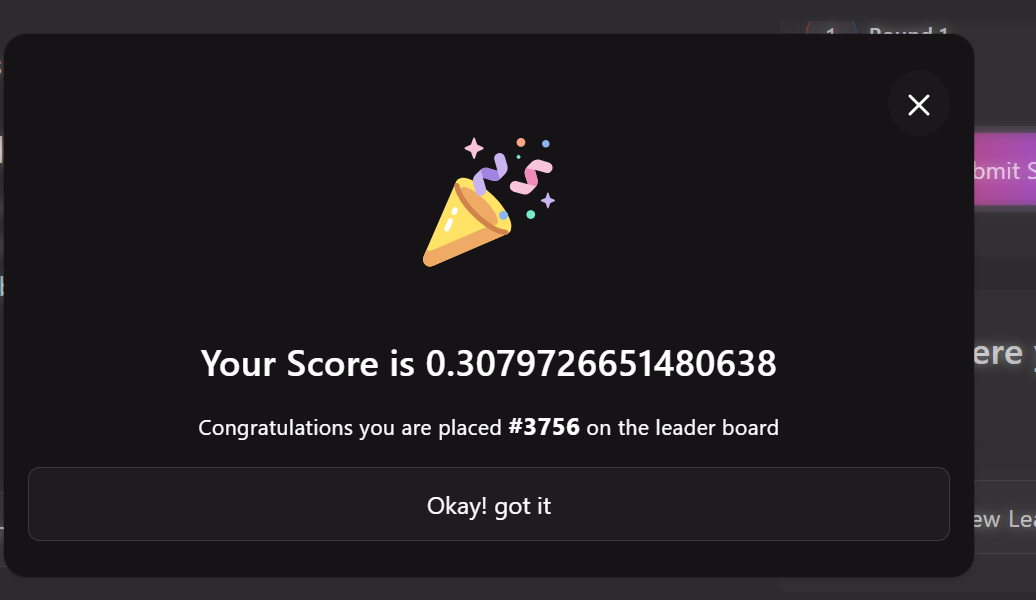